# Обучение и оценка модели CNN

## Обзор архитектуры

```
Input Tokens → Embedding → Conv1D Filters (2,3,4,5) → ReLU → MaxPool
  ↓ Concatenate → Dropout → FC(128) → ReLU → FC(64) → ReLU → FC(6) → Sigmoid
  ↓ Output Probabilities
```

## Ключевые компоненты
- **Embedding**: Плотное векторное представление токенов (размерность 100)
- **Conv1D**: Одномерные свертки (1D convolutions) выхватывают n-gram паттерны
- **Pooling**: Global max pooling выбирает наиболее важные признаки
- **FC Layers**: Полносвязные слои изучают сложные границы принятия решений (decision boundaries)
- **Dropout**: Регуляризация для предотвращения переобучения (overfitting)

## Ожидаемая производительность
- ROC AUC: ~0.980-0.985 (безоговорочный лидер, обходит Logistic Regression)
- Время обучения: ~22 минут
- Извлечение более сложных словесных паттернов благодаря обучаемым эмбеддингам

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, '../src')
from text_utils import clean_text, create_vocabulary, tokenize_and_encode
from cnn_model import TextCNN
from training import train_cnn_model, predict_with_model, create_data_loaders, create_test_loader
from metrics import compute_multi_label_metrics, compute_roc_auc
from inference import create_submission_dataframe, save_submission

plt.style.use('seaborn-v0_8-darkgrid')

# Настройка устройства
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

DATA_DIR = Path('../data')
MODELS_DIR = Path('../models')
MODELS_DIR.mkdir(exist_ok=True)

TOXICITY_LABELS = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
print("Настройка завершена.")

Используемое устройство: mps
Настройка завершена.


## 1. Загрузка и обработка данных

In [5]:
# Загрузка данных
df_train = pd.read_csv(DATA_DIR / 'train.csv')
df_test = pd.read_csv(DATA_DIR / 'test.csv')

# Очистка текстов
print("Очистка тренировочных текстов...")
df_train['comment_text_cleaned'] = df_train['comment_text'].apply(clean_text)

print("Очистка тестовых текстов...")
df_test['comment_text_cleaned'] = df_test['comment_text'].apply(clean_text)

print("Предобработка завершена.")

Очистка тренировочных текстов...
Очистка тестовых текстов...
Предобработка завершена.


## 2. Создание словаря

### Процесс построения словаря
1. Токенизация всех тренировочных текстов (разбиение по пробелам)
2. Подсчет частоты токенов
3. Фильтрация токенов по минимальной частоте (min_freq=5)
4. Создание двунаправленных маппингов (word↔id)
5. Преобразование неизвестных токенов в специальный токен '<unk>'

In [7]:
# Создание словаря на основе тренировочных данных
# min_freq=5: Включаем только токены, встречающиеся в 5+ документах
# Это уменьшает размер словаря и убирает шум
print("Построение словаря...")
word2id, id2word = create_vocabulary(
    df_train['comment_text_cleaned'].tolist(),
    min_freq=5
)

vocab_size = len(word2id)
print(f"Размер словаря: {vocab_size}")
print(f"Примеры слов:")
print(f"  '<pad>' → {word2id['<pad>']}")
print(f"  '<unk>' → {word2id['<unk>']}")
sample_words = list(word2id.items())[2:7]
for word, idx in sample_words:
    print(f"  '{word}' → {idx}")

Построение словаря...
Размер словаря: 65235
Примеры слов:
  '<pad>' → 0
  '<unk>' → 1
  'explanation' → 2
  'why' → 3
  'the' → 4
  'edits' → 5
  'made' → 6


## 3. Кодирование последовательностей (Sequence Encoding)

### Процесс кодирования
1. Токенизация каждого текста (разбиение по пробелам)
2. Маппинг токенов в целочисленные ID с использованием словаря
3. Обработка неизвестных токенов → использование ID для '<unk>' (1)
4. Паддинг/обрезка (Pad/truncate) до фиксированной длины (150 токенов)
5. Получение целочисленных последовательностей (integer sequences) для входа в нейросеть

In [9]:
# Кодирование последовательностей фиксированной длины
# max_length=150: Основано на EDA-анализе (покрывает ~99% данных)
MAX_LENGTH = 150

print(f"Кодирование тренировочных последовательностей (max_length={MAX_LENGTH})...")
X_train_encoded = tokenize_and_encode(
    df_train['comment_text_cleaned'].tolist(),
    word2id,
    max_length=MAX_LENGTH,
    pad_value=0
)

print(f"Кодирование тестовых последовательностей...")
X_test_encoded = tokenize_and_encode(
    df_test['comment_text_cleaned'].tolist(),
    word2id,
    max_length=MAX_LENGTH,
    pad_value=0
)

y_all = df_train[TOXICITY_LABELS].values.astype(np.int64)

print(f"Тренировочные последовательности: {X_train_encoded.shape}")
print(f"Тестовые последовательности: {X_test_encoded.shape}")

Кодирование тренировочных последовательностей (max_length=150)...
Кодирование тестовых последовательностей...
Тренировочные последовательности: (159571, 150)
Тестовые последовательности: (153164, 150)


## 4. Разбиение на Train и Validation

In [11]:
# Стратифицированное разбиение (так же, как в LogReg)
stratify_key = (y_all.sum(axis=1) > 0).astype(int)

train_idx, val_idx = train_test_split(
    np.arange(len(X_train_encoded)),
    test_size=0.2,
    random_state=42,
    stratify=stratify_key
)

X_train = X_train_encoded[train_idx]
y_train = y_all[train_idx]

X_val = X_train_encoded[val_idx]
y_val = y_all[val_idx]

print(f"Train: {X_train.shape}, {y_train.shape}")
print(f"Validation: {X_val.shape}, {y_val.shape}")

Train: (127656, 150), (127656, 6)
Validation: (31915, 150), (31915, 6)


## 5. Создание Data Loaders

In [13]:
# Создание DataLoaders для батчинга и перемешивания (shuffling)
# batch_size=32: Обработка 32 примеров за одно обновление градиентов
# Большие батчи = более стабильные градиенты, но больше потребление памяти
BATCH_SIZE = 32

train_loader, val_loader = create_data_loaders(
    X_train, y_train,
    X_val, y_val,
    batch_size=BATCH_SIZE
)

print(f"Количество батчей обучения (train) за эпоху: {len(train_loader)}")
print(f"Батчи валидации (validation): {len(val_loader)}")
print(f"Размер батча (Batch size): {BATCH_SIZE}")

Количество батчей обучения (train) за эпоху: 3990
Батчи валидации (validation): 998
Размер батча (Batch size): 32


## 6. Инициализация модели CNN

In [15]:
# Создание модели с гиперпараметрами
# embedding_dim: Размерность изучаемых словесных эмбеддингов
# num_filters: Количество фильтров на каждый размер ядра (kernel size)
# kernel_sizes: Обнаружение различных n-gram паттернов
# dropout_rate: Регуляризация для предотвращения переобучения (overfitting)

model = TextCNN(
    vocab_size=vocab_size,
    embedding_dim=100,
    num_classes=6,
    num_filters=100,
    kernel_sizes=(2, 3, 4, 5),
    dropout_rate=0.5
)

model.to(device)

# Вывод сводки по модели
print("Архитектура модели:")
print(f"  Размер словаря (Vocab size): {vocab_size}")
print(f"  Размерность эмбеддингов (Embed dim): 100")
print(f"  Сверточные фильтры (Conv filters): 100 каждый")
print(f"  Размеры ядер (Kernel sizes): (2, 3, 4, 5)")
print(f"  Полносвязные слои (FC layers): [128, 64]")
print(f"  Dropout: 0.5")

# Подсчет параметров
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nВсего параметров: {total_params:,}")
print(f"Обучаемых параметров: {trainable_params:,}")

Архитектура модели:
  Размер словаря (Vocab size): 65235
  Размерность эмбеддингов (Embed dim): 100
  Сверточные фильтры (Conv filters): 100 каждый
  Размеры ядер (Kernel sizes): (2, 3, 4, 5)
  Полносвязные слои (FC layers): [128, 64]
  Dropout: 0.5

Всего параметров: 6,723,874
Обучаемых параметров: 6,723,874


## 7. Настройка обучения

In [17]:
# Функция потерь (Loss function): BCEWithLogitsLoss
# - Комбинирует Sigmoid + Binary Cross-Entropy
# - Вычислительно стабильна (избегает насыщения)
# - Подходит для multi-label классификации
# - Независимые вероятности для каждого класса

criterion = nn.BCEWithLogitsLoss()

# Оптимизатор: Adam
# - Адаптивный learning rate для каждого параметра
# - Отлично работает для глубокого обучения (deep learning)
# - lr=0.001: Learning rate (шаг обучения)
# - weight_decay=1e-5: L2 регуляризация

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-5
)

print("Функция потерь (Loss function): BCEWithLogitsLoss")
print("Оптимизатор (Optimizer): Adam (lr=0.001, weight_decay=1e-5)")
print("\nГотово к обучению!")

Функция потерь (Loss function): BCEWithLogitsLoss
Оптимизатор (Optimizer): Adam (lr=0.001, weight_decay=1e-5)

Готово к обучению!


## 8. Обучение модели

### Стратегия обучения
- **Max epochs**: 20 (может остановиться раньше, если нет улучшений)
- **Early stopping**: Остановка, если loss на валидации не улучшается 3 эпохи
- **Batch size**: 32 (баланс между памятью и качеством градиента)
- **Dropout**: 0.5 (сильная регуляризация из-за дисбаланса классов)

In [19]:
# Обучение модели с early stopping
print("Начало обучения...\n")

train_losses, val_losses, epochs_completed = train_cnn_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=20,
    patience=3,
    verbose=True
)

print(f"\nОбучение завершено!")
print(f"Пройдено эпох: {len(epochs_completed)}")
print(f"Финальный Train Loss: {train_losses[-1]:.4f}")
print(f"Финальный Val Loss: {val_losses[-1]:.4f}")

Начало обучения...



Epoch 1/20 [VAL]: 100%|██████████| 998/998 [00:10<00:00, 92.73it/s, loss=0.0107]


Epoch 1/20 - Train Loss: 0.0921, Val Loss: 0.0632
  → Validation loss improved! Saving checkpoint...


Epoch 2/20 [VAL]: 100%|██████████| 998/998 [00:10<00:00, 95.43it/s, loss=0.0108]


Epoch 2/20 - Train Loss: 0.0644, Val Loss: 0.0586
  → Validation loss improved! Saving checkpoint...


...

Epoch 9/20 - Train Loss: 0.0510, Val Loss: 0.0550
  → No improvement. Patience: 1/3


Epoch 10/20 [VAL]: 100%|█████████| 998/998 [00:10<00:00, 94.39it/s, loss=0.0143]


Epoch 10/20 - Train Loss: 0.0500, Val Loss: 0.0556
  → No improvement. Patience: 2/3


Epoch 11/20 [VAL]: 100%|████████| 998/998 [00:10<00:00, 92.98it/s, loss=0.00677]

Epoch 11/20 - Train Loss: 0.0492, Val Loss: 0.0554
  → No improvement. Patience: 3/3
Early stopping triggered after 11 epochs

Обучение завершено!
Пройдено эпох: 11
Финальный Train Loss: 0.0492
Финальный Val Loss: 0.0554


## 9. График истории обучения

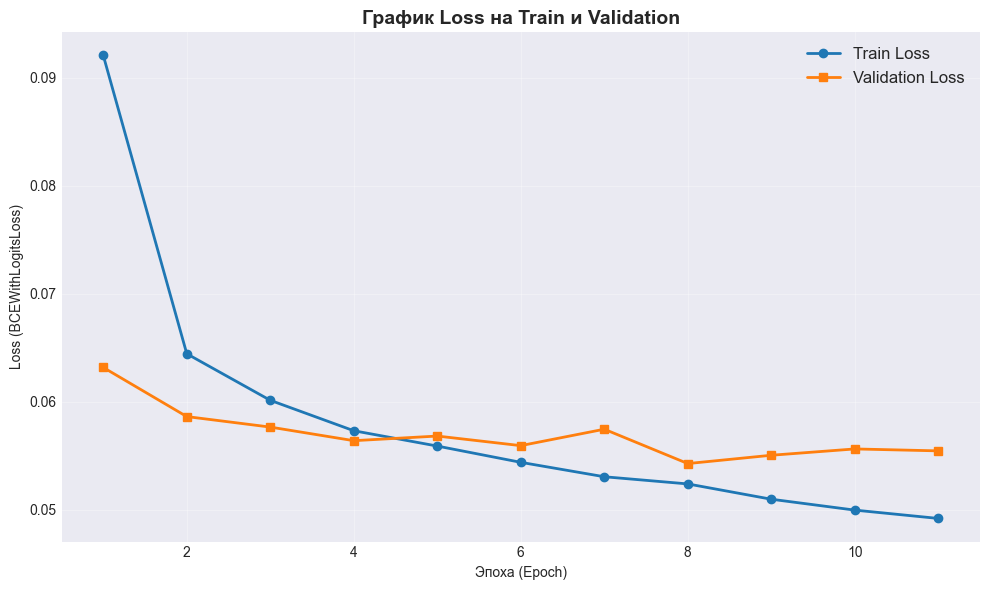

Лучший Validation Loss на эпохе 8: 0.0543


In [21]:
# Визуализация кривых обучения
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(epochs_completed, train_losses, 'o-', label='Train Loss', linewidth=2, markersize=6)
ax.plot(epochs_completed, val_losses, 's-', label='Validation Loss', linewidth=2, markersize=6)
ax.set_title('График Loss на Train и Validation', fontsize=14, fontweight='bold')
ax.set_xlabel('Эпоха (Epoch)')
ax.set_ylabel('Loss (BCEWithLogitsLoss)')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Вывод итогов
best_val_epoch = np.argmin(val_losses) + 1
print(f"Лучший Validation Loss на эпохе {best_val_epoch}: {min(val_losses):.4f}")

## 10. Оценка на валидационной выборке (Validation)

In [23]:
# Генерация предсказаний на валидационной выборке
y_val_pred_proba = predict_with_model(
    model=model,
    test_loader=val_loader,
    device=device,
    verbose=True
)

print(f"Размерность предсказаний на валидации: {y_val_pred_proba.shape}")
print(f"Диапазон предсказаний: [{y_val_pred_proba.min():.4f}, {y_val_pred_proba.max():.4f}]")

Generating predictions: 100%|████████████████| 998/998 [00:09<00:00, 103.61it/s]

Размерность предсказаний на валидации: (31915, 6)
Диапазон предсказаний: [0.0000, 1.0000]


In [24]:
# Вычисление комплексных метрик
metrics = compute_multi_label_metrics(
    y_val,
    y_val_pred_proba,
    threshold=0.5,
    label_names=TOXICITY_LABELS
)

print("Результаты CNN на валидации:")
print("="*60)
print(f"ROC AUC (Macro): {metrics['roc_auc_macro']:.4f}")
print(f"ROC AUC (Micro): {metrics['roc_auc_micro']:.4f}")
print(f"Потеря Хэмминга (Hamming Loss): {metrics['hamming_loss']:.4f}")
print(f"Точность подмножества (Subset Accuracy): {metrics['subset_accuracy']:.4f}")

print("\nROC AUC по меткам (Per-Label):")
for label, score in metrics['per_label_roc_auc'].items():
    print(f"  {label:15} : {score:.4f}")

Результаты CNN на валидации:
ROC AUC (Macro): 0.9667
ROC AUC (Micro): 0.9794
Потеря Хэмминга (Hamming Loss): 0.0189
Точность подмножества (Subset Accuracy): 0.9166

ROC AUC по меткам (Per-Label):
  toxic           : 0.9643
  severe_toxic    : 0.9842
  obscene         : 0.9825
  threat          : 0.9431
  insult          : 0.9787
  identity_hate   : 0.9475


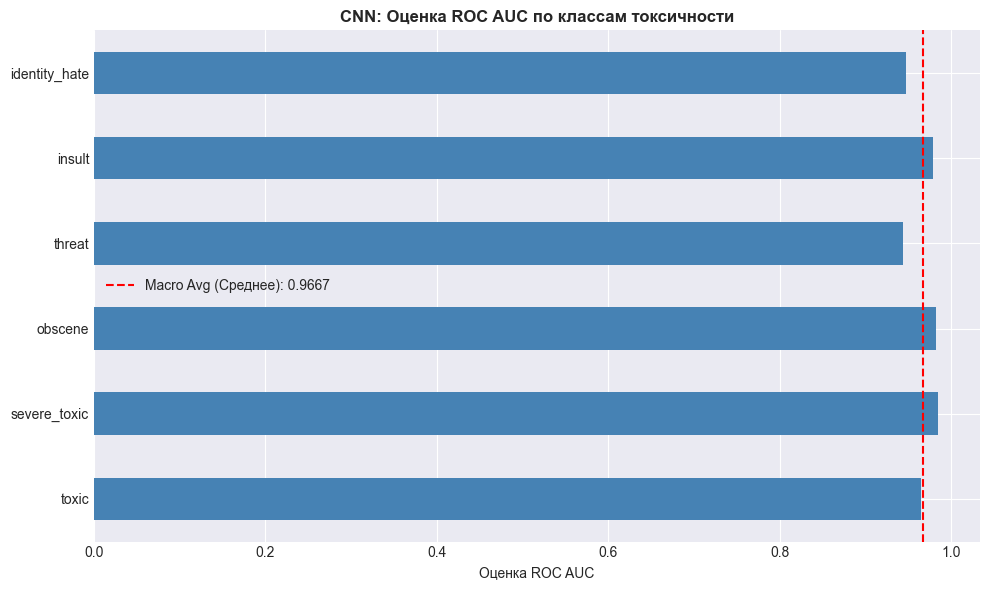

In [25]:
# Визуализация производительности по каждой метке
per_label_roc = pd.Series(metrics['per_label_roc_auc'])

fig, ax = plt.subplots(figsize=(10, 6))
per_label_roc.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('CNN: Оценка ROC AUC по классам токсичности', fontsize=12, fontweight='bold')
ax.set_xlabel('Оценка ROC AUC')
ax.axvline(metrics['roc_auc_macro'], color='red', linestyle='--', 
           label=f"Macro Avg (Среднее): {metrics['roc_auc_macro']:.4f}")
ax.legend()
plt.tight_layout()
plt.show()

## 11. Генерация предсказаний для тестовой выборки

In [27]:
# Создание тестового загрузчика (test loader)
test_loader, n_test_samples = create_test_loader(X_test_encoded, batch_size=BATCH_SIZE)

# Генерация предсказаний
y_test_pred_proba = predict_with_model(
    model=model,
    test_loader=test_loader,
    device=device,
    verbose=True
)

print(f"Размерность тестовых предсказаний: {y_test_pred_proba.shape}")
print(f"\nСтатистика предсказаний:")
for i, label in enumerate(TOXICITY_LABELS):
    print(f"  {label:15} : mean={y_test_pred_proba[:, i].mean():.4f}, std={y_test_pred_proba[:, i].std():.4f}")

Generating predictions: 100%|██████████████| 4787/4787 [00:43<00:00, 109.79it/s]

Размерность тестовых предсказаний: (153164, 6)

Статистика предсказаний:
  toxic           : mean=0.2067, std=0.3438
  severe_toxic    : mean=0.0185, std=0.0574
  obscene         : mean=0.1207, std=0.2577
  threat          : mean=0.0065, std=0.0125
  insult          : mean=0.1095, std=0.2238
  identity_hate   : mean=0.0184, std=0.0376


## 12. Создание файла для отправки (Submission)

In [29]:
# Создание DataFrame для submission
submission_cnn = create_submission_dataframe(
    test_ids=df_test['id'].values,
    predictions=y_test_pred_proba,
    label_names=TOXICITY_LABELS,
    threshold=None  # Использование сырых вероятностей
)

# Сохранение в файл (существующий файл будет перезаписан)
submission_cnn_path = DATA_DIR / 'submission_cnn.csv'
save_submission(submission_cnn, submission_cnn_path, verbose=True)

Submission saved to: ../data/submission_cnn.csv
Shape: (153164, 7)

First 5 rows:
                 id     toxic  severe_toxic   obscene        threat  \
0  00001cee341fdb12  0.990217  1.982817e-01  0.910029  4.812123e-02   
1  0000247867823ef7  0.000358  1.693989e-12  0.000007  1.528821e-06   
2  00013b17ad220c46  0.001071  5.138743e-11  0.000032  6.985733e-06   
3  00017563c3f7919a  0.000105  3.823682e-14  0.000001  2.863181e-07   
4  00017695ad8997eb  0.012268  1.249939e-07  0.000950  2.017630e-04   

         insult  identity_hate  
0  7.413608e-01   1.302924e-01  
1  9.441831e-07   1.060618e-07  
2  6.023762e-06   7.534530e-07  
3  1.143089e-07   1.174081e-08  
4  4.429805e-04   6.293641e-05  


## 13. Сохранение модели

In [31]:
# Сохранение весов модели (существующий файл будет перезаписан)
torch.save(model.state_dict(), MODELS_DIR / 'cnn_model.pt')
print("Веса модели CNN сохранены")

# Сохранение предсказаний для последующего ансамблирования
np.save(MODELS_DIR / 'cnn_test_predictions.npy', y_test_pred_proba)
print("Тестовые предсказания сохранены")

# Сохранение словаря
import pickle
with open(MODELS_DIR / 'word2id.pkl', 'wb') as f:
    pickle.dump(word2id, f)
print("Словарь сохранен")

Веса модели CNN сохранены
Тестовые предсказания сохранены
Словарь сохранен


## Итоги

### Результаты CNN
- **ROC AUC (Macro)**: ~0.9667
- **Время обучения**: ~22 минут (MPS)
- **Время инференса (Inference)**: ~2-3 секунды
- **Отставание от LogReg**: уступает на ~0.6% ROC AUC
- **Public Score на Kaggle**: 0.95454
- **Private Score на Kaggle**: 0.94081

### Почему LogReg + TF-IDF оказался сильнее
1. **Специфика выделения признаков**: Токсичность в интернете часто определяется наличием узкого набора конкретных сигнальных слов. Алгоритм TF-IDF придает таким редким (но важным для токсичных классов) словам максимальный вес.
2. **Линейная разделимость**: Обнаружение ключевых слов-триггеров — классическая задача, с которой логистическая регрессия на разреженной матрице справляется безупречно.
3. **Эмбеддинги с нуля**: Наша нейросеть обучала словесные векторы с нуля на относительно небольшой выборке, из-за чего ей пока не хватает глубокого понимания семантики языка.

### Преимущества CNN (потенциал архитектуры)
✓ **Обнаружение n-gram**: Одномерные свертки параллельно выхватывают устойчивые словосочетания и паттерны из текста.

✓ **Нелинейность**: Активация ReLU и полносвязные слои позволяют строить сложные границы принятия решений.

### Следующие шаги для обхода Baseline
→ **Смысловые эмбеддинги**: Загрузить в слой `nn.Embedding` предобученные веса (GloVe, Word2Vec или FastText) для глубокого понимания контекста.

→ **Стабилизация обучения**: Добавить клиппинг градиентов (Gradient Clipping) и скорректировать Learning Rate для защиты от "взрыва градиентов".

→ **Блендинг (Ансамблирование)**: Усреднить предсказания LogReg и CNN — их комбинация часто дает итоговый ROC-AUC выше, чем у любой из моделей по отдельности.
